In [94]:
### Business Problem

"""
Financial market data provider wants to understand:

1. Understand Customer behaviour
2. Predict Churn
3. Forecast revenue
4. Analyse pricing Competitiveness
5. identify pricing opportunity
6. segment customers
7. recommend pricing actions

SUCCESS METRICS

1. Revenue growth 
2. Churn Reduction
3. Competitive Pricing
4. Customer Retention

"""

'\nFinancial market data provider wants to understand:\n\n1. Understand Customer behaviour\n2. Predict Churn\n3. Forecast revenue\n4. Analyse pricing Competitiveness\n5. identify pricing opportunity\n6. segment customers\n7. recommend pricing actions\n\nSUCCESS METRICS\n\n1. Revenue growth \n2. Churn Reduction\n3. Competitive Pricing\n4. Customer Retention\n\n'

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# model related libs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Algos
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

# import metrics

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# warnings
import warnings
warnings.filterwarnings("ignore")

In [96]:
df = pd.read_csv("market_pricing_data_100_rows.csv")
df.head()

,Client_ID,Client_Type,Region,Product,Subscription_Tier,Monthly_Fee,Trading_Volume,Usage_Hours,Support_Tickets,Contract_Length,Market_Volatility,Competitor_Price,Revenue,Churn,Month
0,C001,Broker,Americas,FX Feed,Basic,3509,60275,66,12,28,21.91,3410,3942.02,1,2024-01-01
1,C002,Asset Manager,EMEA,FX Feed,Professional,654,73369,48,12,20,13.15,449,956.87,1,2024-01-02
2,C003,Bank,EMEA,Fixed Income Feed,Basic,3037,12938,118,13,42,32.12,3376,2755.61,0,2024-01-03
3,C004,Broker,EMEA,FX Feed,Professional,1909,36195,190,2,26,15.47,1703,2310.58,0,2024-01-04
4,C005,Broker,EMEA,Fixed Income Feed,Basic,4557,92680,51,12,19,26.92,4672,5259.33,0,2024-01-05


In [97]:
df.shape 

(100, 15)

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Client_ID          100 non-null    object 
 1   Client_Type        100 non-null    object 
 2   Region             100 non-null    object 
 3   Product            100 non-null    object 
 4   Subscription_Tier  100 non-null    object 
 5   Monthly_Fee        100 non-null    int64  
 6   Trading_Volume     100 non-null    int64  
 7   Usage_Hours        100 non-null    int64  
 8   Support_Tickets    100 non-null    int64  
 9   Contract_Length    100 non-null    int64  
 10  Market_Volatility  100 non-null    float64
 11  Competitor_Price   100 non-null    int64  
 12  Revenue            100 non-null    float64
 13  Churn              100 non-null    int64  
 14  Month              100 non-null    object 
dtypes: float64(2), int64(7), object(6)
memory usage: 11.8+ KB


In [99]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly_Fee,100.0,2805.1000,1269.768002,504.00,1649.500,2967.000,3753.5000,4995.00
Trading_Volume,100.0,52602.6100,29041.264819,1412.00,28035.500,54016.000,76714.0000,98856.00
Usage_Hours,100.0,153.2700,76.828532,10.00,88.000,161.500,214.2500,292.00
Support_Tickets,100.0,6.5000,4.715116,0.00,2.000,6.000,11.0000,14.00
Contract_Length,100.0,25.5000,11.541318,6.00,16.000,26.000,34.2500,47.00
Market_Volatility,100.0,25.6518,8.666492,10.08,18.950,26.465,32.6475,39.92
Competitor_Price,100.0,2809.1600,1310.844995,404.00,1686.000,2791.000,3792.2500,5387.00
Revenue,100.0,3182.9009,1638.004467,711.14,1843.425,2920.140,4343.3075,7263.01
Churn,100.0,0.1400,0.348735,0.00,0.000,0.000,0.0000,1.00


In [100]:
df.isnull().sum()

Client_ID            0
Client_Type          0
Region               0
Product              0
Subscription_Tier    0
Monthly_Fee          0
Trading_Volume       0
Usage_Hours          0
Support_Tickets      0
Contract_Length      0
Market_Volatility    0
Competitor_Price     0
Revenue              0
Churn                0
Month                0
dtype: int64

In [101]:
df.duplicated().sum()

np.int64(0)

In [102]:
df.nunique()

Client_ID            100
Client_Type            4
Region                 3
Product                3
Subscription_Tier      3
Monthly_Fee           99
Trading_Volume       100
Usage_Hours           84
Support_Tickets       15
Contract_Length       42
Market_Volatility     97
Competitor_Price     100
Revenue              100
Churn                  2
Month                100
dtype: int64

In [103]:
df['Revenue'].describe()

count     100.000000
mean     3182.900900
std      1638.004467
min       711.140000
25%      1843.425000
50%      2920.140000
75%      4343.307500
max      7263.010000
Name: Revenue, dtype: float64

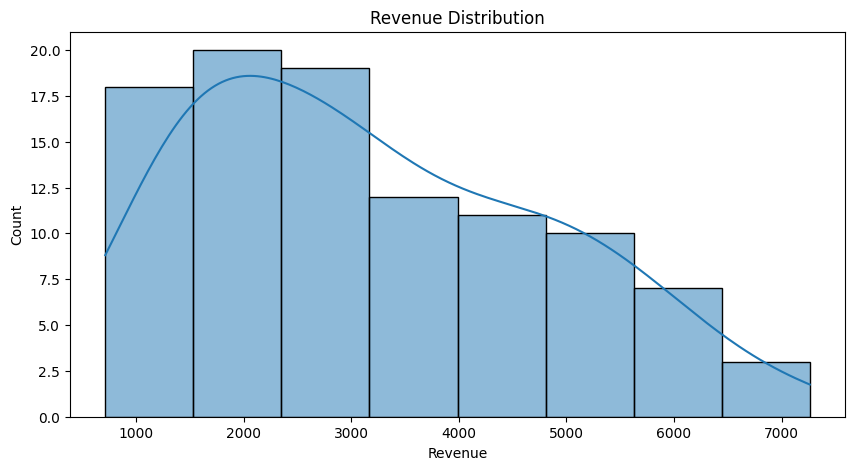

In [104]:
plt.figure(figsize=(10,5))

sns.histplot(df['Revenue'],kde= True)
plt.title("Revenue Distribution")
plt.show()

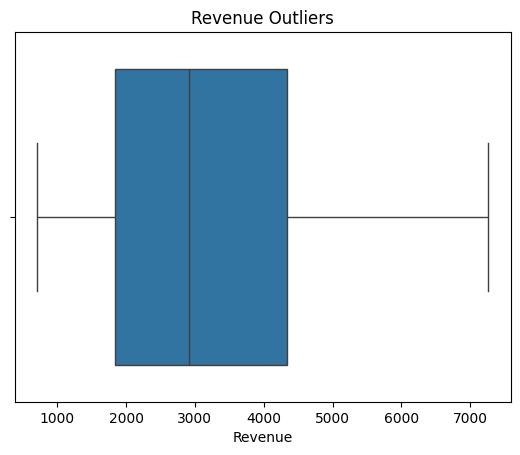

In [105]:
sns.boxplot(x=df['Revenue'])

plt.title("Revenue Outliers")
plt.show()

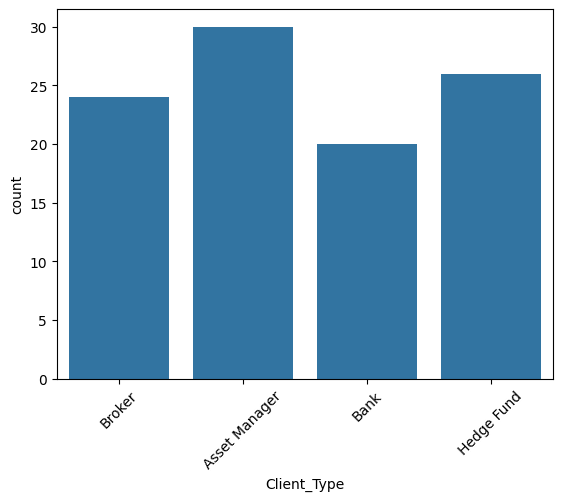

In [106]:
sns.countplot(x='Client_Type',data=df)
plt.xticks(rotation=45)
plt.show()

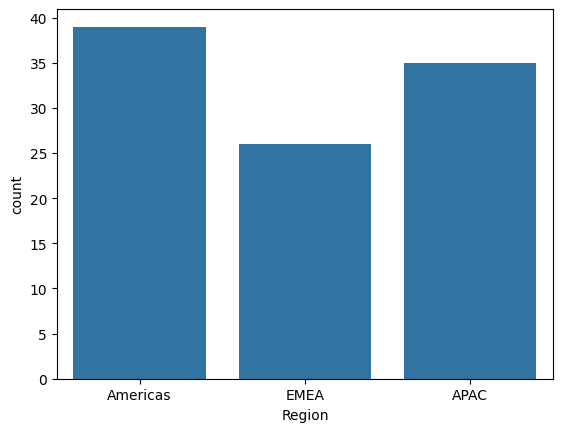

In [107]:
sns.countplot(x='Region', data= df)
plt.show()

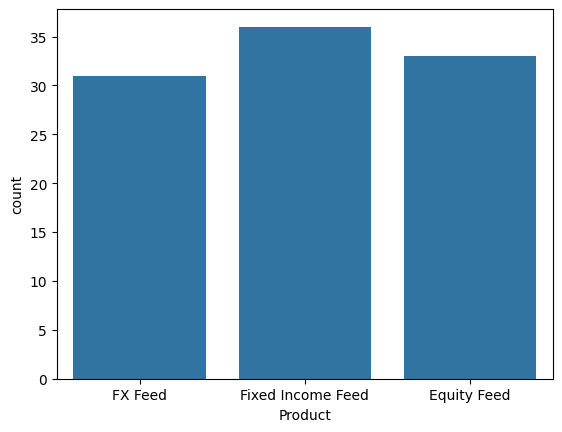

In [108]:
sns.countplot(x='Product', data=df)
plt.show()

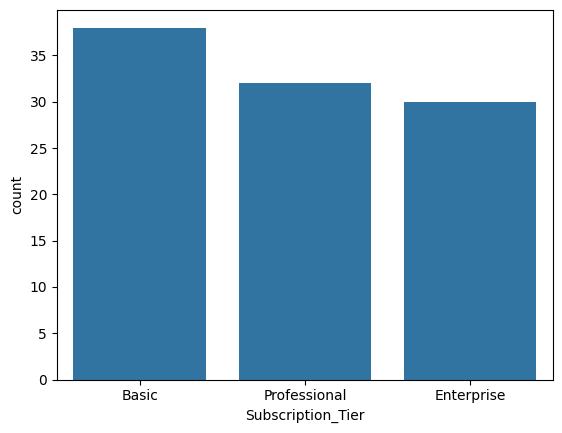

In [109]:
sns.countplot(x='Subscription_Tier',data=df)
plt.show()

#Revenue analysis

In [110]:
df.groupby('Product')['Revenue'].mean().sort_values(ascending=False)

Product
Equity Feed          3328.177273
Fixed Income Feed    3306.395833
FX Feed              2884.838387
Name: Revenue, dtype: float64

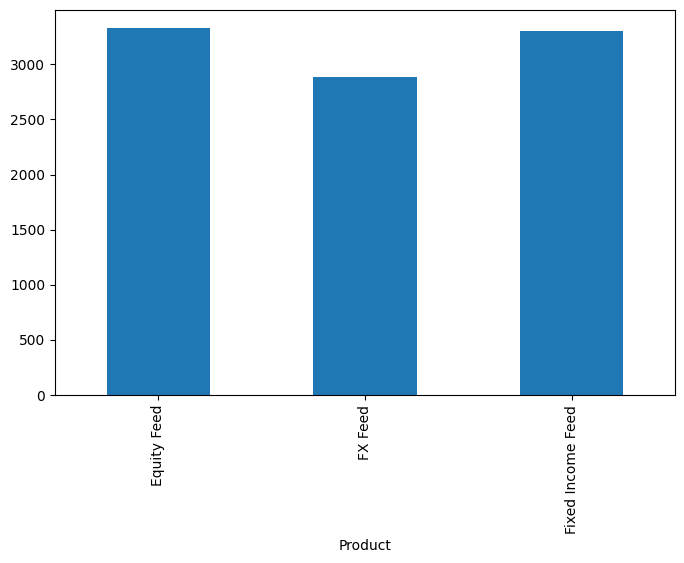

In [111]:
plt.figure(figsize=(8,5))
df.groupby('Product')['Revenue'].mean().plot(kind='bar')
plt.show()

In [112]:
df.groupby('Client_Type')['Revenue'].sum()

Client_Type
Asset Manager    92614.35
Bank             64454.41
Broker           76890.96
Hedge Fund       84330.37
Name: Revenue, dtype: float64

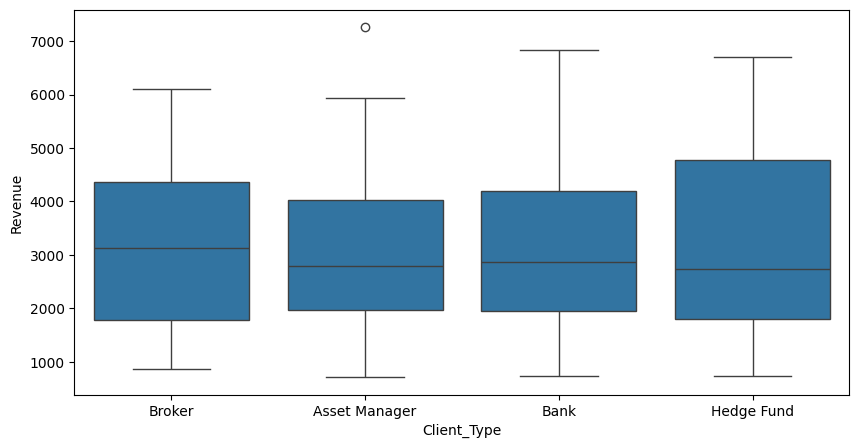

In [113]:
plt.figure(figsize=(10,5))

sns.boxplot(x='Client_Type',y='Revenue',data=df)
# plt.xticks(rotations=45)
plt.show()

In [114]:
df['Churn'].value_counts()

Churn
0    86
1    14
Name: count, dtype: int64

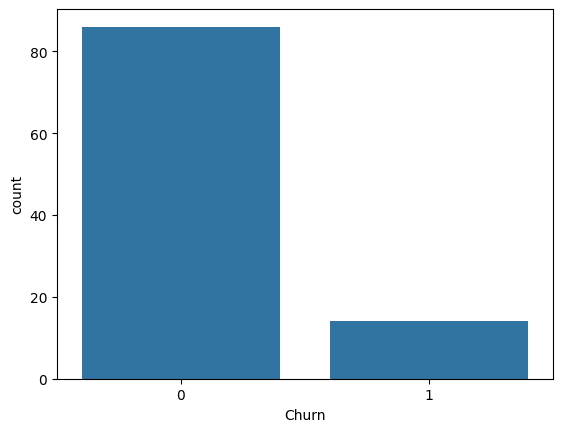

In [115]:
sns.countplot(x='Churn',data=df)
plt.show()

In [116]:
churn_rate = (df['Churn'].mean()*100)

print(churn_rate)

14.000000000000002


In [117]:
df.groupby('Product')['Churn'].mean()*100

Product
Equity Feed           9.090909
FX Feed               9.677419
Fixed Income Feed    22.222222
Name: Churn, dtype: float64

In [118]:
df['Price_Gap'] = ((df['Monthly_Fee']-df['Competitor_Price'])/df['Competitor_Price'])*100

In [119]:
df['Revenue_Per_Hour'] = (df['Revenue']/df['Usage_Hours'])

In [120]:
df['Volume_Per_Dollar'] = (df['Trading_Volume']/df['Monthly_Fee'])

In [121]:
df.head()

,Client_ID,Client_Type,Region,Product,Subscription_Tier,Monthly_Fee,Trading_Volume,Usage_Hours,Support_Tickets,Contract_Length,Market_Volatility,Competitor_Price,Revenue,Churn,Month,Price_Gap,Revenue_Per_Hour,Volume_Per_Dollar
0,C001,Broker,Americas,FX Feed,Basic,3509,60275,66,12,28,21.91,3410,3942.02,1,2024-01-01,2.903226,59.727576,17.177258
1,C002,Asset Manager,EMEA,FX Feed,Professional,654,73369,48,12,20,13.15,449,956.87,1,2024-01-02,45.657016,19.934792,112.185015
2,C003,Bank,EMEA,Fixed Income Feed,Basic,3037,12938,118,13,42,32.12,3376,2755.61,0,2024-01-03,-10.041469,23.352627,4.260125
3,C004,Broker,EMEA,FX Feed,Professional,1909,36195,190,2,26,15.47,1703,2310.58,0,2024-01-04,12.096301,12.160947,18.960189
4,C005,Broker,EMEA,Fixed Income Feed,Basic,4557,92680,51,12,19,26.92,4672,5259.33,0,2024-01-05,-2.461473,103.124118,20.337942


#Correlation Analysis

In [122]:
numeric_cols = df.select_dtypes(include=np.number)
corr = numeric_cols.corr()

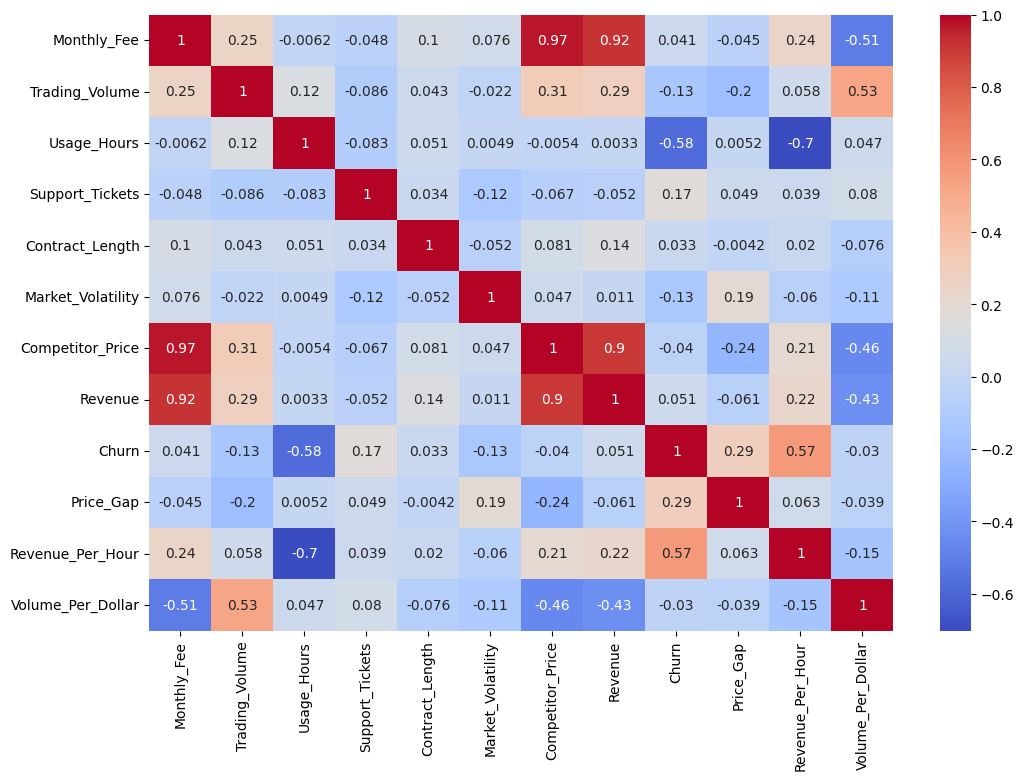

In [123]:
plt.figure(figsize=(12,8))
sns.heatmap(
    corr,annot=True,cmap='coolwarm'
)

plt.show()

#Encoding

In [124]:
cat_cols = ['Client_Type','Region','Product','Subscription_Tier']


In [125]:
encoder = LabelEncoder()
for cols in cat_cols:
    df[cols] = encoder.fit_transform(df[cols])

**Segment data

In [126]:
segment_data = df[['Revenue', 'Trading_Volume','Usage_Hours']]


In [127]:
scaler = StandardScaler()
segment_scaled = scaler.fit_transform(segment_data)

In [128]:
wcss = []

for i in range(1,11):
    km = KMeans(n_clusters=i,random_state=42)
    km.fit(segment_scaled)
    wcss.append(km.inertia_)
    

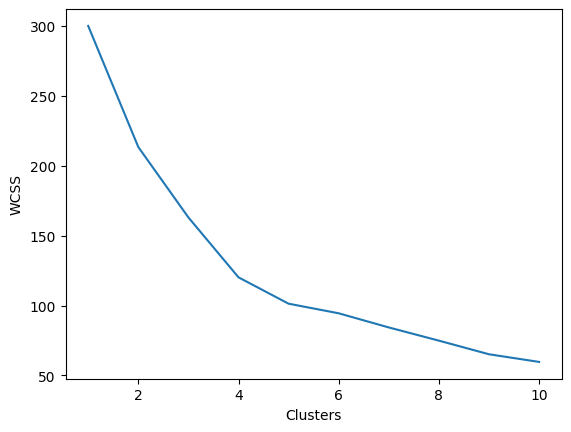

In [129]:
plt.plot(range(1,11),wcss)
plt.xlabel('Clusters')
plt.ylabel('WCSS')
plt.show()

In [130]:
kmeans = KMeans(n_clusters=4,random_state=42)
df['Segment'] = kmeans.fit_predict(segment_scaled)

In [131]:
df['Segment'].value_counts()

Segment
0    28
1    27
3    24
2    21
Name: count, dtype: int64

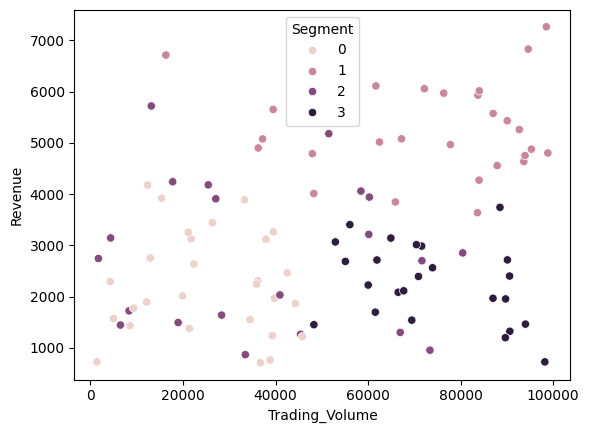

In [132]:
sns.scatterplot(x='Trading_Volume',y='Revenue',hue='Segment',data=df)
plt.show()

#Churn Prediction

In [133]:
X= df.drop(['Churn','Client_ID','Month'], axis = 1)
y=df['Churn']


In [134]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [135]:
model = RandomForestClassifier(n_estimators=300,max_depth=8,random_state=42)


In [136]:
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [137]:
pred = model.predict(X_test)

In [138]:
print(accuracy_score(y_test,pred))

0.95


In [139]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        16
           1       1.00      0.75      0.86         4

    accuracy                           0.95        20
   macro avg       0.97      0.88      0.91        20
weighted avg       0.95      0.95      0.95        20



In [140]:
confusion_matrix(y_test,pred)

array([[16,  0],
       [ 1,  3]])

In [141]:
## Feature Importance

importance = pd.DataFrame({'Feature':X.columns,'Importance':model.feature_importances_})

In [142]:
importance.sort_values('Importance',ascending=False)

,Feature,Importance
6,Usage_Hours,0.237625
13,Revenue_Per_Hour,0.169541
12,Price_Gap,0.161224
14,Volume_Per_Dollar,0.075951
9,Market_Volatility,0.073131
5,Trading_Volume,0.041847
10,Competitor_Price,0.041412
15,Segment,0.035216
8,Contract_Length,0.034003
1,Region,0.028726


##Revenue Prediction

In [143]:
X = df.drop(['Revenue','Client_ID','Month'],axis = 1)
y = df['Revenue']


In [144]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [145]:
reg = RandomForestRegressor(n_estimators=500,random_state=42)

In [146]:
reg.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [147]:
pred = reg.predict(X_test)

In [148]:
print(r2_score(y_test,pred))

0.8667231568972581


In [149]:
print(mean_absolute_error(y_test,pred))
print(mean_squared_error(y_test,pred))

492.27966100000293
331651.2396921363


##Price Elasticity Analysis

In [150]:
X= df[['Monthly_Fee']]
y = df[['Trading_Volume']]

In [151]:
lr = LinearRegression()
lr.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [152]:
print("Coefficient",lr.coef_[0])

Coefficient [5.7149708]


hence low price sensitive as positive coefficient


##Competitor Analysis

In [153]:
# df['Price_Gap']
df['Competitor_Difference_%']=df['Price_Gap']

In [154]:
df['Competitor_Difference_%']

0      2.903226
1     45.657016
2    -10.041469
3     12.096301
4     -2.461473
        ...    
95   -30.762852
96    -3.393352
97     9.975537
98   -13.508323
99    27.969573
Name: Competitor_Difference_%, Length: 100, dtype: float64

In [155]:
df['Competitor_Difference_%'].describe()

count    100.000000
mean       1.547791
std       15.319686
min      -30.762852
25%       -9.286293
50%       -1.371504
75%       10.757348
max       52.475248
Name: Competitor_Difference_%, dtype: float64

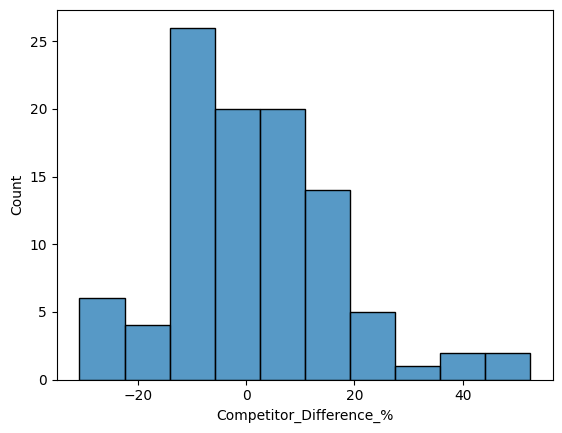

In [156]:
sns.histplot(df['Competitor_Difference_%'])
plt.show()

##Pricing Recommendation Engine

In [157]:
def pricing_action(row):
    if row['Price_Gap'] < -200:
        return 'Increase Price'
    elif row['Price_Gap'] > 200:
        return 'Decrease Price'
    else:
        return 'Maintain Price'

In [158]:
df['Pricing_Action'] = df.apply(pricing_action,axis=1)

In [159]:
df[['Client_ID','Monthly_Fee','Price_Gap','Pricing_Action']]

,Client_ID,Monthly_Fee,Price_Gap,Pricing_Action
0,C001,3509,2.903226,Maintain Price
1,C002,654,45.657016,Maintain Price
2,C003,3037,-10.041469,Maintain Price
3,C004,1909,12.096301,Maintain Price
4,C005,4557,-2.461473,Maintain Price
...,...,...,...,...
95,C096,835,-30.762852,Maintain Price
96,C097,1395,-3.393352,Maintain Price
97,C098,4046,9.975537,Maintain Price
98,C099,1351,-13.508323,Maintain Price


In [160]:
kpi = pd.DataFrame({
    'Metric':[
        'Total_Revenue',
        'Average_Revenue',
        'Churn_Rate',
        'Average_Price'
    ],
    'Values':
        [
            df['Revenue'].sum(),
            df['Revenue'].mean(),
            df['Churn'].mean()*100,
            df['Monthly_Fee'].mean()
        ]
})

In [161]:
kpi

,Metric,Values
0,Total_Revenue,318290.0900
1,Average_Revenue,3182.9009
2,Churn_Rate,14.0000
3,Average_Price,2805.1000
